# Trabajo Práctico N°11 del TPS: Python Markov Chain Monte Carlo (PyMC)

En este trabajo práctico se analiza una celda fotovoltaica a partir de mediciones experimentales de tensión para distintas cargas.

El objetivo es estimar los parámetros internos del modelo eléctrico equivalente, aun cuando esos parámetros no se observan de forma directa.

Para eso, primero se plantea el modelo físico del circuito y se obtiene la relación matemática entre la tensión medida y los parámetros desconocidos. Luego, esa relación se incorpora en un modelo bayesiano con PyMC.

De esta manera, en lugar de obtener un único valor por parámetro, se obtiene una distribución de valores posibles y su nivel de incertidumbre, lo que permite interpretar los resultados con mayor solidez.

Se importan todas las librerías que se utilizarán a lo largo de este TP.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import lambertw, wrightomega
import pymc as pm
import pytensor
import pytensor.tensor as pt
import pytensor.scalar as ps
import arviz as az

Para mayor compresión del modelo físico a resolver, en la siguiente imagen se puede apreciar el mismo.

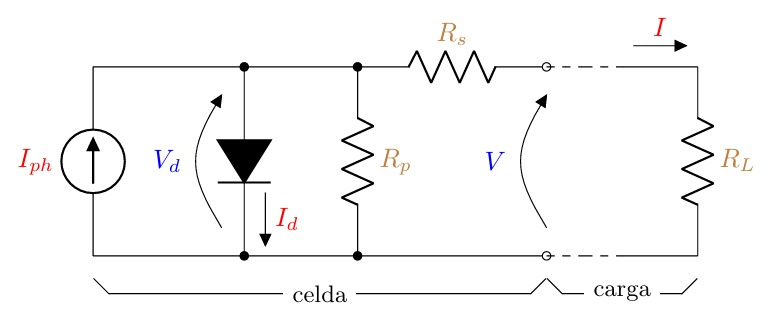

## (a) Modelado Físico

El circuito equivalente de la celda fotovoltaica (ver imagen de la celda anterior) consiste en una fuente de corriente $I_{ph}$ (fotocorriente), un diodo ideal en paralelo, una resistencia de pérdidas en paralelo $R_p$, y una resistencia serie $R_s$. La carga $R_L$ se conecta en los terminales de salida. A partir de este circuito se plantean las ecuaciones que vinculan la tensión de carga $V$ con los parámetros del modelo.

Esta vinculación es central porque, en los datos experimentales, la magnitud observable es $V$ para distintos valores de $R_L$, mientras que los parámetros internos de la celda no se miden de forma directa. Por lo tanto, expresar $V$ como función de esos parámetros permite resolver el problema inverso: inferir $I_{ph}$, $I_0$, $n$, $R_s$ y $R_p$ a partir de las mediciones.

### 1. Ley de Kirchoff de Corrientes

Aplicando KCL en el nodo de la tensión de diodo $V_d$, la fotocorriente $I_{ph}$ se divide en una corriente por el diodo, otra por la resistencia paralela $R_p$ y la corriente de carga $I$.

Primero se relacionan las tensiones y corrientes del lazo serie $R_s$-$R_L$:

$$V = I\,R_L, \qquad V_d = I\,(R_s+R_L)$$

Reemplazando $I = V/R_L$ en la segunda ecuación:

$$V_d = \frac{V(R_s+R_L)}{R_L}$$

Luego, por KCL en el nodo superior del circuito equivalente:

$$I_{ph} = I_d + I_{R_p} + I$$

con

$$I_d = I_0\!\left(e^{\frac{V_d}{nV_T}}-1\right), \qquad I_{R_p}=\frac{V_d}{R_p}, \qquad I=\frac{V}{R_L}$$

Finalmente, sustituyendo $V_d = V(R_s+R_L)/R_L$ en cada término, se obtiene:

$$I_{ph} = I_0\left(e^{\frac{V(R_s+R_L)}{n V_T R_L}} - 1\right) + \frac{V(R_s+R_L)}{R_p R_L} + \frac{V}{R_L}$$

Así es como se obtiene a la tensión de salida ($V$) en función de los parámetros internos del modelo. Esta ecuación, al reescribir por Lambert en la siguiente celda quedará de manera explícita:

$$V=f(R_L, I_{ph}, I_0, n, R_s, R_p)$$

### 2. Función de Lambert

La ecuación obtenida en el punto anterior mezcla dos comportamientos al mismo tiempo:
- un término exponencial en $V$ (por el diodo),
- y términos lineales en $V$ (por $R_p$ y $R_L$).

Esa combinación impide despejar $V$ con álgebra elemental. En otras palabras, el problema directo (calcular $V$ para una carga $R_L$ dada) queda en una forma implícita.

Para resolverlo de manera cerrada, se usa la función $W$ de Lambert, definida por:

$$W(z)e^{W(z)}=z$$

Esta función aparece justamente cuando una variable está a la vez multiplicando y dentro de una exponencial. Ese es exactamente el tipo de estructura que surge en el modelo de la celda.

Se define además $h(x)=W(e^x)$ para trabajar de forma más estable en términos logarítmicos.

Partiendo de la KCL ya obtenida:

$$I_{ph}=I_0\left(e^{\frac{V(R_s+R_L)}{nV_TR_L}}-1\right)+\frac{V(R_s+R_L)}{R_pR_L}+\frac{V}{R_L}$$

se reordena como:

$$I_0\,e^{\frac{V(R_s+R_L)}{nV_TR_L}}=I_{ph}+I_0-V\left(\frac{R_s+R_L}{R_pR_L}+\frac{1}{R_L}\right)$$

Definiendo

$$I_e=I_0\,e^{\frac{V(R_s+R_L)}{nV_TR_L}}, \qquad a=\frac{R_s+R_L}{nV_TR_L}, \qquad b=\frac{R_s+R_L}{R_pR_L}+\frac{1}{R_L},$$

queda:

$$I_e=I_{ph}+I_0-bV$$

y por lo tanto

$$V=\frac{I_{ph}+I_0-I_e}{b}$$

Sustituyendo esta expresión de $V$ en la definición de $I_e$:

$$I_e=I_0\exp\!\left(a\,\frac{I_{ph}+I_0-I_e}{b}\right)$$

Reordenando:

$$I_e\,e^{\frac{a}{b}I_e}=I_0\,e^{\frac{a}{b}(I_{ph}+I_0)}$$

Ahora se define

$$C=\frac{a}{b}=\frac{R_p(R_s+R_L)}{nV_T(R_s+R_L+R_p)}$$

y se obtiene la forma canónica:

$$\big(CI_e\big)e^{CI_e}=CI_0\,e^{C(I_{ph}+I_0)}$$


Aplicando la función de Lambert, sea:

$$
x = C I_e
$$

entonces:

$$
x e^x = C I_0\, e^{C(I_{ph}+I_0)}
$$

Por definición de Lambert:

$$
x = W\!\left(C I_0\, e^{C(I_{ph}+I_0)}\right)
$$

Volviendo a $I_e$:

$$
C I_e = W\!\left(C I_0\, e^{C(I_{ph}+I_0)}\right)
$$


Para escribir $h(x)=W(e^x)$, se usa la identidad:

$$
a\,e^b = e^{\ln(a)+b}
$$

Entonces:

$$
C I_0\, e^{C(I_{ph}+I_0)} = e^{\ln(C I_0) + C(I_{ph}+I_0)}
$$

Por lo tanto:

$$
W\!\left(C I_0\, e^{C(I_{ph}+I_0)}\right)
= W\!\left(e^{\ln(C I_0) + C(I_{ph}+I_0)}\right)
= h\!\left(\ln(C I_0) + C(I_{ph}+I_0)\right)
$$

Finalmente, como $V=(I_{ph}+I_0-I_e)/b$ y $1/b=\dfrac{R_pR_L}{R_s+R_L+R_p}$, resulta:

$$V=\frac{R_pR_L}{R_s+R_L+R_p}\left[I_{ph}+I_0-\frac{h\!\left(\ln(I_0C)+C(I_{ph}+I_0)\right)}{C}\right]$$

Con esto, el modelo queda en forma explícita para $V$, lo cual permite evaluar la tensión predicha para cada $R_L$ dentro del modelo bayesiano.

### 3. Derivada de la función de Lambert

La razón para calcular esta derivada no es física sino computacional. El algoritmo de muestreo de PyMC (NUTS) necesita el gradiente del modelo respecto a los parámetros para explorar el espacio de probabilidad de forma eficiente. Como el modelo incluye la función $h(x) = W(e^x)$, cuya derivada el motor de diferenciación automática no conoce, es necesario proveerla de forma explícita. Cómo esto se traduce en código quedará más claro en la sección de implementación.

#### Derivada de $W(z)$

La función de Lambert está definida implícitamente por $W(z)\,e^{W(z)} = z$. Derivando ambos lados respecto de $z$ y aplicando regla del producto:

$$1 = W'(z)\,e^{W(z)}\big(1 + W(z)\big)$$

Despejando $W'(z)$:

$$W'(z) = \frac{1}{e^{W(z)}(1 + W(z))}$$

Usando la definición original para reemplazar $e^{W(z)} = z/W(z)$:

$$W'(z) = \frac{W(z)}{z(1 + W(z))}$$

#### Derivada de $h(x)$

Aplicando regla de la cadena a $h(x) = W(e^x)$:

$$h'(x) = W'(e^x)\cdot e^x = \frac{W(e^x)}{e^x(1 + W(e^x))} \cdot e^x = \frac{W(e^x)}{1 + W(e^x)}$$

Expresado en términos de $h(x)$:

$$h'(x) = \frac{h(x)}{1 + h(x)}$$

Esta forma es conveniente para la implementación porque el gradiente queda expresado directamente en términos del valor de la función, sin necesidad de recalcular la exponencial.


## (b) Exploración de Datos

La base de datos `pv.csv` contiene mediciones de tensión de la celda fotovoltaica para diferentes resistencias de carga. Se carga el dataset y se grafica la tensión $V$ en función de la resistencia de carga $R_L$.

In [3]:
url = "https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/pv.csv"
fname = "pv.csv"

if not os.path.exists(fname):
    import urllib.request
    urllib.request.urlretrieve(url, fname)
    print("Dataset descargado.")
else:
    print("Dataset ya disponible en sesión.")

df = pd.read_csv(fname)
print(df.head())
print(f"\nColumnas: {list(df.columns)}")
print(f"Dimensiones: {df.shape}")

Dataset descargado.
         RL         V
0  0.003334  0.004952
1  0.003815  0.000000
2  0.004296  0.000000
3  0.004777  0.003245
4  0.005258  0.000000

Columnas: ['RL', 'V']
Dimensiones: (500, 2)


A partir de la inspección inicial, se observa que la columna `RL` tiene los valores de las resistencias expresadas en ohmios. Mientras que la columna `V` presenta valores los valores de la tensión en volts. Cabe mencionar también que hay 500 datos de cada una de las dos variables.

Para comprender mejor la distribución de los datos, se analiza a continuación el rango efectivo de cada variable, la proporción de mediciones con tensión nula, y se grafican los histogramas de $R_L$ y $V$ junto con la curva $V$ vs. $R_L$ en escala logarítmica.

=== Estadísticas descriptivas ===
               RL           V
count  500.000000  500.000000
mean     0.302336    0.370352
std      0.761673    0.208720
min      0.003334    0.000000
25%      0.063348    0.191485
50%      0.123584    0.369465
75%      0.220513    0.551672
max      9.480029    0.741493

=== Rangos ===
RL: [0.0033, 9.48] Ω  —  factor 2844x
V:  [0.000000, 0.7415] V
Valores V == 0: 3 (0.6%)


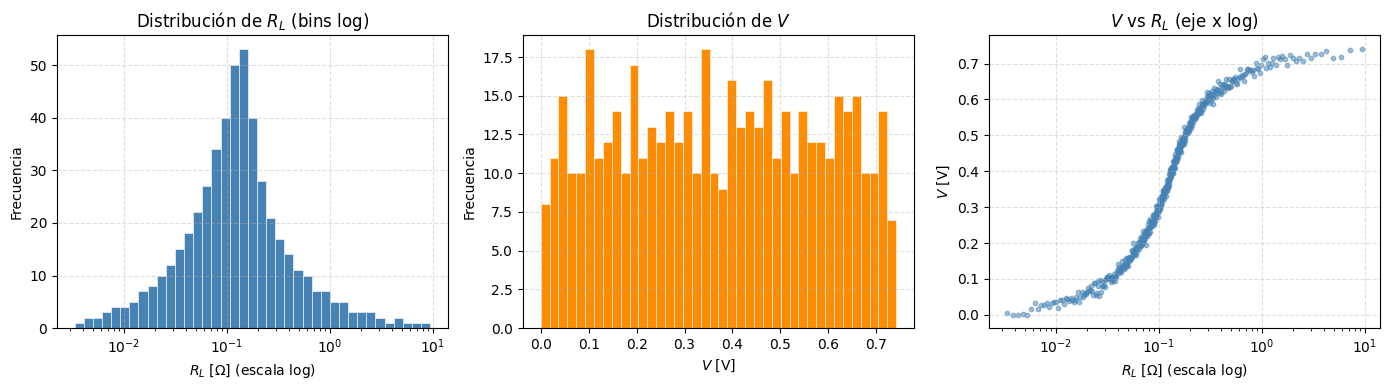

In [4]:
RL = df.iloc[:, 0].values
V  = df.iloc[:, 1].values

print("=== Estadísticas descriptivas ===")
print(df.describe().to_string())

print(f"\n=== Rangos ===")
print(f"RL: [{RL.min():.4f}, {RL.max():.2f}] Ω  —  factor {RL.max()/RL.min():.0f}x")
print(f"V:  [{V.min():.6f}, {V.max():.4f}] V")
print(f"Valores V == 0: {(V == 0).sum()} ({(V == 0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histograma RL con bins logarítmicos (frecuencia por intervalos multiplicativos)
log_bins = np.logspace(np.log10(RL.min()), np.log10(RL.max()), 40)
axes[0].hist(RL, bins=log_bins, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_xscale("log")
axes[0].set_xlabel(r"$R_L$ [$\Omega$] (escala log)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de $R_L$ (bins log)")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Histograma V
axes[1].hist(V, bins=40, color="darkorange", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("$V$ [V]")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de $V$")
axes[1].grid(True, linestyle="--", alpha=0.4)

# V vs RL (escala log en x)
axes[2].scatter(RL, V, s=10, color="steelblue", alpha=0.5)
axes[2].set_xscale("log")
axes[2].set_xlabel(r"$R_L$ [$\Omega$] (escala log)")
axes[2].set_ylabel("$V$ [V]")
axes[2].set_title("$V$ vs $R_L$ (eje x log)")
axes[2].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


A partir de las estadísticas descriptivas y de los gráficos, se observa un comportamiento consistente con el modelo físico de una celda fotovoltaica.

La tensión medida queda acotada entre 0 y 0.7415 V, por lo que el valor máximo constituye una aproximación razonable de la tensión de circuito abierto ($V_{OC}\approx 0.74$ V). En el extremo de cargas muy bajas, la tensión se aproxima a 0 V, como se espera en condición cercana al cortocircuito.

Es importante distinguir dos ideas: estar cerca de $V_{OC}$ no implica circuito abierto estricto. El circuito abierto ideal ocurre cuando $R_L\to\infty$ y la corriente de salida es nula ($I=0$). En cambio, para $R_L\approx 9.5\,\Omega$ la corriente aún es finita.

Por lo tanto, en el extremo alto de $R_L$ medido se observa un régimen cuasi abierto (tensión casi saturada), pero no circuito abierto ideal. Aun así, los datos sugieren que, para esta celda y bajo estas condiciones de medición, una carga del orden de $10\,\Omega$ ya ubica al punto de operación muy cerca del régimen de circuito abierto.

La razón física de esta saturación es que, al aumentar $V$, la corriente del diodo crece de forma exponencial. En consecuencia, una fracción cada vez mayor de la fotocorriente se deriva internamente (diodo y $R_p$), y queda menos corriente para la carga externa. Por eso, incrementos adicionales en $R_L$ producen cambios cada vez menores en $V$, que se aproxima asintóticamente a $V_{OC}$.

Por otro lado, la variable de carga presenta un rango muy amplio ($R_L\in[0.0033,\,9.48]$ $\Omega$), con un factor de 2844x entre mínimo y máximo. Este barrido es favorable porque permite observar la respuesta de la celda en regímenes muy distintos de operación. Por eso, el uso de escala logarítmica en $R_L$ resulta adecuado para interpretar la relación $V$-$R_L$.

El histograma de $R_L$ (con bins logarítmicos) muestra además que la mayor densidad de mediciones se concentra en valores intermedios, alrededor de $10^{-1}\,\Omega$, mientras que en los extremos (muy baja y muy alta carga) hay menos observaciones. Esto implica que el ajuste estará más informado en la región intermedia y, potencialmente, con mayor incertidumbre en los extremos.

El histograma de tensión $V$ se observa aproximadamente uniforme en gran parte del intervalo $[0,\,0.74]$ V, con menor frecuencia relativa en los extremos. Esta cobertura amplia en tensión es favorable para la inferencia, aunque esa forma no debe interpretarse como linealidad física del sistema, sino como resultado del barrido de $R_L$ combinado con la respuesta no lineal de la celda.

La nube $V$ vs $R_L$ en escala logarítmica muestra una transición no lineal clara:
- zona de baja tensión para cargas pequeñas,
- región intermedia de crecimiento pronunciado,
- meseta para cargas grandes, cercana a $V_{OC}$.

Esta forma es la esperada para un modelo con diodo y resistencias internas ($R_s$, $R_p$), y sugiere que los datos contienen información suficiente para identificar parámetros del circuito equivalente en el enfoque bayesiano.

Además, la proporción de valores exactamente nulos en tensión es baja (0.6%), por lo que no se observa, en principio, un problema de censura severa en la medición.

#### Hipótesis sobre los Parámetros del Modelo



Antes de configurar el modelo en PyMC, los datos permiten acotar el comportamiento esperado de algunos parámetros.



**Tensión de circuito abierto y fotocorriente.** El máximo de tensión observado es $V_{\max} \approx 0.74$ V. En régimen de circuito abierto ideal, la corriente de carga es nula y toda la fotocorriente circula por el diodo. De la ecuación del diodo en ese límite se obtiene $V_{OC} \approx n V_T \ln(I_{ph}/I_0)$. Dado que $V_{OC}/V_T \approx 28$, la relación $I_{ph}/I_0$ es del orden de $e^{28} \approx 10^{12}$: la fotocorriente debe ser muchísimo mayor que $I_0$.



En cortocircuito ($R_L \to 0$), la caída en $R_s$ es despreciable y prácticamente toda $I_{ph}$ alimenta la carga. El punto de menor $R_L$ del dataset ($R_L \approx 0.003\,\Omega$, $V \approx 0.005$ V) da $I \approx V/R_L \approx 1.5$ A, lo que indica que **$I_{ph}$ es del orden de 1–2 A**.



**Forma de la curva y resistencias internas.** La transición suave desde $V \approx 0$ en baja carga hasta la meseta en alta carga indica que $R_s$ es pequeña (sin caídas bruscas) y que $R_p$ es lo suficientemente grande como para no derivar corriente interna de forma excesiva. Si $R_p$ fuera del mismo orden que $R_L$, la curva no alcanzaría la meseta observada.



- $R_s$ debe ser **menor, o a lo sumo del mismo orden pero más pequeña que $R_{L,\min} \approx 0.003\,\Omega$**, ya que si $R_s$ fuese comparable o mayor, aparecería una caída interna apreciable incluso en la zona cercana al cortocircuito. Esta es una restricción heurística de orden de magnitud, no una cota exacta.

- $R_p$ debe ser **grande respecto de las cargas barridas** (rango 0.003–9.5 Ω), por lo que se espera $R_p \gg 10\,\Omega$, probablemente en el orden de $10^2$–$10^3\,\Omega$.



**Factor de idealidad e $I_0$.** Para silicio estándar se espera $n \approx 1$ e $I_0 \approx 10^{-10}$ A. La posterior podrá evidenciar desviaciones si el dispositivo presenta defectos o recombinación no ideal.



**Ruido de medición.** Con solo 0.6% de valores nulos y una distribución de tensión sin censura evidente, el ruido de medición se espera bajo y aproximadamente gaussiano, del orden de $\sigma \approx 0.01$–$0.05$ V.



**Resumen de rangos esperados:**



| Parámetro | Valor esperado | Fundamento |
|-----------|--------------|------------|
| $I_{ph}$  | 1–2 A        | corriente de cortocircuito medida |
| $I_0$     | $\sim 10^{-10}$ A | saturación inversa, silicio típico |
| $n$       | $\approx 1$  | idealidad, silicio estándar |
| $R_s$     | $\lesssim 0.003\,\Omega$ | restricción heurística desde la zona cercana al cortocircuito |
| $R_p$     | $\gg 10\,\Omega$ | meseta clara en alta carga |
| $\sigma$  | 0.01–0.05 V  | resolución instrumental estimada |



Si la posterior arroja valores fuera de estos rangos, será indicativo de que el modelo o los datos requieren revisión.


## (c) Modelado en PyMC

En este inciso se traduce el modelo físico de la celda fotovoltaica a un modelo bayesiano en PyMC. Para ello se implementa la función no lineal basada en Lambert W de forma diferenciable y vectorizada, se definen las distribuciones a priori de los parámetros y se especifica la verosimilitud de las mediciones. Este paso establece la base computacional necesaria para realizar, en el inciso siguiente, la inferencia a posteriori de los parámetros del circuito equivalente.

### 1) Implementación de $h(x)=W(e^x)$ en PyTensor

En el inciso (d) se utilizará el modelo PyMC para samplear el modelo Bayesiano. Para ello, PyMC necesita calcular gradientes automáticos de la verosimilitud respecto a los parámetros (es decir, derivadas para explorar bien el espacio).

El problema es que la función de Lambert $W(e^x)$ no es una operación estándar que PyTensor conozca. Si se intentara ustilizar $W(e^x)$ sin decirle a PyTensor cómo derivarla, el sampler fallará o será ineficiente.

La solución es registrar la función de Lambert como una operación personalizada en PyTensor, y le decirle explícitamente cómo se deriva.

$$\frac{d}{dx}W(e^x) = \frac{W(e^x)}{1 + W(e^x)}$$

De esta forma, cuando PyMC samplee el modelo en (d), los gradientes fluirán correctamente y la cadena de diferenciación automática funcionará sin problemas.

In [5]:
class LambertExpOp(ps.UnaryScalarOp):
    def impl(self, x):
        return np.float64(lambertw(np.exp(x)).real)

    def grad(self, inputs, gout):
        (x,) = inputs
        (dx,) = gout
        h = self(x)
        return [dx * h / (1.0 + h)]


lambert_exp_scalar = LambertExpOp(ps.upgrade_to_float, name="lambert_exp_scalar")

### 2) Vectorización con `Elemwise`

En esta etapa se transforma la función escalar $h(x)=W(e^x)$ en un operador que pueda aplicarse directamente sobre vectores. Esto permite usarla dentro de PyTensor en forma eficiente y compatible con el grafo computacional.

Objetivo: validar que la función ya está lista para trabajar con arreglos de datos reales antes de integrarla al modelo probabilístico.

Analogía: es equivalente a medir un módulo con un tester antes de conectarlo al circuito completo. Primero se verifica que el bloque, por sí solo, responde bien; después se integra al sistema grande con menor riesgo de errores difíciles de diagnosticar.

In [6]:
lambert_exp = pytensor.tensor.elemwise.Elemwise(
    lambert_exp_scalar,
    name="lambert_exp"
)

# Verificación rápida sobre un vector
x_test = np.array([-2.0, -0.5, 0.0, 1.0], dtype=np.float64)
print("h(x) = W(e^x):", lambert_exp(x_test).eval())

h(x) = W(e^x): [0.12002824 0.40467385 0.56714329 1.        ]


La salida de la celda anterior es:

$$
h(x)=W(e^x)=[0.1200,\;0.4047,\;0.5671,\;1.0000]
$$

Esta salida se interpreta como la evaluación de la función sobre cada componente del vector de entrada

$$
x=[-2,\,-0.5,\,0,\,1].
$$

Es decir:

$$
h(x)=\big[h(-2),\,h(-0.5),\,h(0),\,h(1)\big].
$$

Por lo tanto, no se trata de una transformación lineal de álgebra matricial ni de una operación que mezcle componentes. Es una transformación punto a punto: cada valor de entrada produce su propio valor de salida en la misma posición del vector.

La coherencia del resultado puede verificarse con dos chequeos simples:

**Monotonía en el rango probado.** Los valores obtenidos cumplen

$$
0.1200 < 0.4047 < 0.5671 < 1.0000,
$$

lo que indica que, al aumentar $x$, también aumenta $h(x)$ en este tramo.

**Caso de control en $x=1$.** Como $h(x)=W(e^x)$, para $x=1$ se tiene

$$
h(1)=W(e)=1,
$$

porque $W(z)$ se define por $W(z)e^{W(z)}=z$ y, en particular, $1\cdot e^1=e$.

En términos prácticos, esta celda confirma que la implementación de $h(x)$ funciona correctamente sobre vectores y que puede integrarse al modelo bayesiano con un comportamiento numérico consistente.

### 3) Construcción del modelo bayesiano en PyMC

En este punto se traduce el modelo físico obtenido en el inciso (a) a un modelo probabilístico dentro del framework PyMC.

La idea central es pasar de una descripción determinística del sistema (una ecuación que vincula la tensión con los parámetros) a una descripción bayesiana, donde los parámetros son tratados como variables aleatorias. Esto permite incorporar incertidumbre y, posteriormente, estimar dichos parámetros a partir de los datos experimentales.

En particular, los parámetros del modelo ($I_{ph}$, $I_0$, $R_s$, $R_p$, $n$ y $\sigma$) ya no se consideran valores fijos, sino variables desconocidas a las que se les asignan distribuciones a priori. Estas distribuciones reflejan el conocimiento previo sobre el sistema, tanto desde el punto de vista físico como experimental:

- $I_{ph}$ y $n$ se modelan con distribuciones *normales*, ya que se espera que estén alrededor de ciertos valores típicos.
- $I_0$ se modela como *log-normal*, lo que asegura positividad y permite representar variaciones en órdenes de magnitud.
- $R_s$, $R_p$ y $\sigma$ se modelan como *half-normal*, lo que garantiza que tomen únicamente valores positivos, coherente con su interpretación física.



#### ¿De dónde sale $V_{\mu}$ y qué tiene que ver Lambert?

La ecuación del circuito para la tensión es implícita (aparece $V$ adentro y afuera de la exponencial), por eso no se puede despejar con álgebra elemental. En el inciso (a) se reescribe esa ecuación en una forma que permite usar la función de Lambert $W$.

Con esa transformación se define una función cerrada $V(R_L;\theta)$, donde
$\theta=(I_{ph}, I_0, R_s, R_p, n)$,
y esa misma función es la que en PyMC se implementa como media del modelo:

$$
V_{\mu} = V(R_L;\theta)
$$

En el código se implementa vía la variable auxiliar $x$ y la función
$h(x)=W(e^x)$ (es decir, `lambert_exp(x)`) para mantener estabilidad numérica.

Finalmente, se especifica el modelo de medición: las tensiones observadas se consideran realizaciones de una variable aleatoria con distribución normal centrada en $V_{\mu}$ y desviación estándar $\sigma$:

$$
V_{obs} \sim \mathcal{N}(V_{\mu},\sigma)
$$

Así, $V_{\mu}$ representa la predicción física (sin ruido) y $\sigma$ captura el ruido experimental de las mediciones.

Con esto, el modelo queda completamente definido y listo para ser utilizado en el proceso de inferencia bayesiana, donde se estimarán las distribuciones a posteriori de los parámetros a partir de los datos.

In [7]:
Vt = 0.0259

# Limpieza mínima para evitar observaciones no finitas en la likelihood
RL_arr = np.asarray(RL, dtype=np.float64)
V_arr = np.asarray(V, dtype=np.float64)
mask = np.isfinite(RL_arr) & np.isfinite(V_arr) & (RL_arr > 0.0)
RL_use = RL_arr[mask]
V_use = V_arr[mask]
if mask.sum() < RL_arr.size:
    print(f"Se filtraron {RL_arr.size - mask.sum()} filas no válidas antes del modelo.")

with pm.Model() as model_pv:
    RL_data = pm.Data("RL_data", RL_use)

    # Priors según enunciado
    Iph = pm.Normal("Iph", mu=3.0, sigma=1.0)
    I0 = pm.LogNormal("I0", mu=-10.0, sigma=1.0)
    Rs = pm.HalfNormal("Rs", sigma=1.0)
    Rp = pm.HalfNormal("Rp", sigma=500.0)
    n = pm.TruncatedNormal("n", mu=1.2, sigma=0.2, lower=0.6, upper=2.2)
    sigma = pm.HalfNormal("sigma", sigma=0.01)

    # Problema directo V(RL; theta) usando h(x)=W(e^x) con guardas numéricas
    eps = 1e-12
    den = pt.clip(n * Vt * (Rs + RL_data + Rp), eps, np.inf)
    C = Rp * (Rs + RL_data) / den
    C = pt.clip(C, eps, 1e6)
    x = pt.log(pt.clip(I0 * C, eps, np.inf)) + C * (Iph + I0)

    V_mu_raw = (Rp * RL_data / (Rs + RL_data + Rp)) * (Iph + I0 - lambert_exp(x) / C)
    invalid = pt.or_(pt.isnan(V_mu_raw), pt.isinf(V_mu_raw))
    V_mu = pt.clip(pt.switch(invalid, 0.0, V_mu_raw), -1.0, 1.5)
    pm.Deterministic("V_mu", V_mu)

    # Modelo de medición
    pm.Normal("V_obs", mu=V_mu, sigma=sigma, observed=V_use)

print(model_pv)

### 4) Grafo de la red bayesiana

En este punto se visualiza el modelo bayesiano construido en la etapa anterior mediante un grafo que representa explícitamente sus dependencias probabilísticas.

La idea no es obtener un resultado numérico, sino validar y comprender la estructura del modelo. En particular, este gráfico permite identificar de forma clara qué variables son aleatorias (parámetros), cuáles son determinísticas (relaciones físicas) y cómo todas ellas se vinculan con los datos observados.

A través de esta representación, se puede verificar si:
1. Los parámetros a priori están correctamente definidos.
2. La ecuación del modelo físico ($V_{\mu}$) depende de las variables esperadas.
3. La variable observada está correctamente condicionada por el modelo de medición.

Además, el grafo facilita la interpretación del flujo de información dentro del modelo, mostrando cómo los parámetros influyen en la tensión estimada y, a su vez, cómo esta se relaciona con las mediciones experimentales.



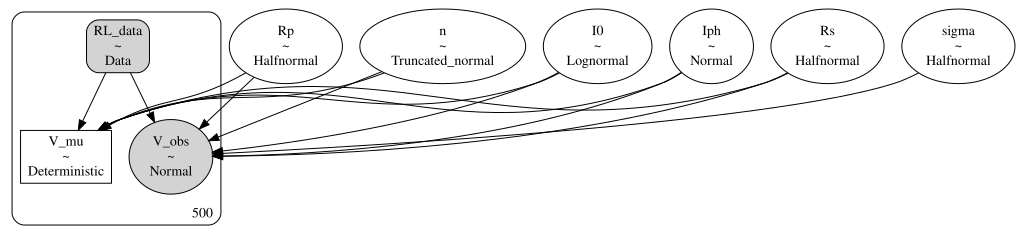

In [8]:
pm.model_to_graphviz(model_pv)

El grafo obtenido refleja de manera adecuada la estructura general del modelo bayesiano construido en el punto anterior. En particular, se observan correctamente diferenciados tres bloques principales: los parámetros a priori, el modelo físico (expresado mediante $V_\mu$) y el modelo de medición ($V_{obs}$).

Los parámetros $I_{ph}$, $I_0$, $R_s$, $R_p$ y $n$ aparecen como variables aleatorias independientes con sus respectivas distribuciones a priori, mientras que $\sigma$ controla exclusivamente el ruido del modelo de medición. Esta separación es coherente con la formulación del problema, donde $\sigma$ no interviene en la ecuación física sino únicamente en la dispersión de las observaciones.

Por otro lado, la variable $V_\mu$ se identifica como una variable determinística que depende tanto de los parámetros del modelo como de los datos de entrada $R_L$. Esto está en línea con el planteo físico: $V_\mu$ representa la tensión esperada según el modelo de la celda fotovoltaica.

La variable $V_{obs}$, por su parte, aparece como una variable aleatoria con distribución normal, dependiente de $V_\mu$ y $\sigma$, lo que corresponde al modelo de medición adoptado.

Un punto importante a destacar es que en el grafo se observan conexiones directas desde los parámetros hacia $V_{obs}$. Sin embargo, estas dependencias deben interpretarse como **indirectas**, ya que en el modelo conceptual los parámetros influyen en $V_{obs}$ a través de $V_\mu$. Es decir, la relación correcta sigue siendo:

Parámetros $\to V_\mu \to V_{obs}$

La representación gráfica utilizada por PyMC tiende a "aplanar" el grafo, mostrando dependencias indirectas como si fueran directas. Esto no implica un error en la implementación, sino una simplificación en la visualización de las dependencias dentro del grafo computacional.

Finalmente, el recuadro que agrupa $V_\mu$ y $V_{obs}$ junto con la anotación "500" indica que el modelo se aplica de manera vectorizada sobre 500 observaciones, lo cual es consistente con el tamaño del conjunto de datos utilizado.

En conjunto, el grafo confirma que el modelo está correctamente especificado, tanto desde el punto de vista probabilístico como físico, y que las relaciones entre parámetros, modelo y datos son coherentes con el planteo del problema.

## (d) Muestreo en PyMC

En este inciso se explica, de manera completa, qué hace PyMC en el contexto de este trabajo, por qué se eligió y cómo interpretar correctamente el resultado del muestreo.

### 1) ¿Cuál es el problema que se quiere resolver?

En los datos experimentales se observa la tensión $V$ para distintos valores de carga $R_L$.
Sin embargo, los parámetros del modelo físico de la celda
$$
\theta = (I_{ph}, I_0, R_s, R_p, n)
$$
no se observan de forma directa.

Por lo tanto, el problema es de inferencia inversa: a partir de datos medidos con ruido, estimar qué valores de $\theta$ son compatibles con el modelo físico y con las observaciones.

### 2) Enfoque bayesiano: prior, likelihood y posterior

El enfoque bayesiano combina tres piezas fundamentales:

1. **Prior** $p(\theta)$: conocimiento previo sobre parámetros antes de mirar los datos.
2. **Likelihood** $p(y\mid\theta)$: probabilidad de observar los datos $y$ si los parámetros fueran $\theta$.
3. **Posterior** $p(\theta\mid y)$: conocimiento actualizado luego de observar los datos.

Estas cantidades se relacionan por el teorema de Bayes:
$$
p(\theta\mid y) = \frac{p(y\mid\theta)\,p(\theta)}{p(y)} \propto p(y\mid\theta)\,p(\theta).
$$

Como $p(y)$ no depende de $\theta$, en la práctica de muestreo se trabaja con la proporcionalidad.

En este TP, la predicción física se escribe como $V_\mu(R_L;\theta)$ y el modelo de medición se define como:
$$
V_{obs,i} \sim \mathcal{N}\big(V_{\mu,i}(\theta),\sigma\big), \qquad i=1,\dots,N.
$$

donde $V_\mu(\theta)$ es determinístico (está dado por el modelo físico), y la incertidumbre se introduce a través del ruido gaussiano de medición.

### 3) Diferencia entre MLE, MAP y posterior completa

Esta distinción es clave para entender qué hace PyMC y qué no hace.

**MLE (Maximum Likelihood Estimation):**
$$
\hat\theta_{MLE} = \arg\max_{\theta} p(y\mid\theta).
$$
Busca un único valor óptimo que maximiza la verosimilitud.

**MAP (Maximum A Posteriori):**
$$
\hat\theta_{MAP} = \arg\max_{\theta} p(\theta\mid y) = \arg\max_{\theta} p(y\mid\theta)p(\theta).
$$
También devuelve un único valor, pero incorporando el prior.

Ambos enfoques son estimadores puntuales: resumen toda la información en un solo valor de $\theta$.

Sin embargo, en este problema esto puede ser insuficiente, ya que:

- el modelo es no lineal,
- hay ruido de medición,
- pueden existir múltiples combinaciones de parámetros que expliquen los datos de forma similar,
- puede haber correlaciones entre parámetros.

**Inferencia bayesiana completa (objetivo de PyMC en este trabajo):**

No busca solo un punto, sino caracterizar la distribución posterior completa $p(\theta\mid y)$.

En lugar de devolver un único valor “óptimo”, PyMC genera muchas muestras de parámetros compatibles con los datos y el modelo. Esto lo hace a través del MCMC que genera muestras del vector completo de parámetros $\theta$, de manera que esas muestras ya siguen la distribución posterior, y a partir de ellas se obtienen las distribuciones marginales, la incertidumbre y las relaciones entre los parámetros.

A partir de estas muestras se obtiene:

- qué valores de $\theta$ son plausibles,
- qué tan probable es cada uno,
- cuánta incertidumbre hay en cada parámetro,
- cómo se relacionan entre sí.

Por lo tanto, PyMC no resuelve un problema de optimización ni busca un único mejor valor, sino que caracteriza completamente la incertidumbre del problema.

Esta información es especialmente importante en sistemas físicos no lineales, donde distintos parámetros pueden compensarse entre sí y producir salidas similares.

### 4) ¿Por qué no se resuelve en forma analítica?

En este problema, la relación entre parámetros y tensión es no lineal e involucra la función de Lambert.

Esto hace que la posterior conjunta sea compleja y no tenga una forma cerrada simple para integrar o normalizar exactamente.

Por este motivo, se recurre a métodos numéricos de muestreo.

### 5) ¿Qué es MCMC y qué hace en términos concretos?

MCMC (Markov Chain Monte Carlo) construye una secuencia
$$
\theta^{(1)},\theta^{(2)},\dots,\theta^{(S)}
$$
de forma tal que, luego de un período de adaptación (burn-in), estas muestras están aproximadamente distribuidas según la posterior $p(\theta\mid y)$.

En otras palabras, MCMC no busca un único valor “verdadero”, sino que explora el espacio de parámetros y genera muestras representativas de la incertidumbre posterior.

Con estas muestras se pueden estimar:

- medias y medianas posteriores,
- intervalos creíbles (por ejemplo HDI 94%),
- desviaciones estándar,
- correlaciones entre parámetros,
- predicción posterior de la salida $V$.

Nota: el HDI (Highest Density Interval) es el intervalo donde está concentrado el 94% de la probabilidad posterior, en las zonas más probables.

### 6) ¿Qué hace PyMC internamente para muestrear en este caso?

Para variables continuas, PyMC usa por defecto NUTS (No-U-Turn Sampler), una variante de HMC (Hamiltonian Monte Carlo).

A diferencia de métodos simples como random walk (que proponen movimientos aleatorios), NUTS utiliza información del gradiente de la log-posterior para explorar el espacio de parámetros de manera más eficiente.

La log-posterior puede escribirse como:
$$
\log p(\theta\mid y) = \log p(y\mid\theta) + \log p(\theta) + C.
$$

El gradiente respecto a $\theta$:
$$
\nabla_\theta \log p(\theta\mid y)
$$
indica en qué dirección aumenta la probabilidad posterior.

La idea de HMC/NUTS es usar este gradiente para construir trayectorias en el espacio de parámetros, de modo que:

- se mueve más rápidamente por regiones de baja probabilidad,
- sigue las “curvaturas” de la distribución,
- y recorre eficientemente las zonas de alta probabilidad.

En lugar de dar pasos pequeños y aleatorios, el algoritmo simula dinámicas inspiradas en sistemas físicos (tipo movimiento con inercia), lo que permite realizar saltos largos pero dirigidos.

NUTS no solo utiliza el gradiente para definir la dirección de movimiento en el espacio de parámetros, sino que además ajusta automáticamente la longitud de la trayectoria (es decir, cuánto avanzar siguiendo esa dirección), evitando tener que fijar manualmente este valor como en HMC y deteniendo el movimiento cuando comienza a retroceder sobre sí mismo (“no U-turn”).

El gradiente se evalúa en la log-posterior completa, lo que implica que depende tanto de la likelihood (datos) como del prior.

Esto explica por qué en este TP fue necesario implementar correctamente la derivada de $h(x)=W(e^x)$ en PyTensor: sin gradientes correctos del modelo completo, NUTS no puede calcular las direcciones de movimiento y el muestreo deja de ser confiable o directamente falla.

### 7) ¿Qué significa "encontrar los parámetros" en Bayes?

En un enfoque frecuentista puntual, "encontrar" suele significar estimar un único valor óptimo.

En Bayes, "encontrar" significa caracterizar una distribución de valores plausibles para cada parámetro, condicionada a los datos y al prior.

Para cada parámetro se reporta típicamente:

- una medida central (media o mediana posterior),
- un intervalo creíble,
- una medida de dispersión,
- su relación con otros parámetros.

Además, la amplitud de las distribuciones a posteriori refleja directamente la incertidumbre en la identificación de cada parámetro, lo que puede indicar falta de información en los datos o correlaciones entre parámetros.

### 8) ¿Por qué se eligió PyMC para este problema?

PyMC es adecuado en este TP por varias razones:

1. Permite escribir el modelo probabilístico de forma explícita y legible.
2. Maneja correctamente modelos no lineales complejos.
3. Usa samplers avanzados (NUTS/HMC) eficientes en espacios continuos.
4. Proporciona diagnósticos de convergencia como $\hat{R}$ (que permite verificar si múltiples cadenas han convergido al mismo comportamiento) y el ESS (que mide la cantidad efectiva de muestras independientes obtenidas).
5. Se integra con ArviZ, que permite analizar las muestras generadas, calcular estadísticas posteriores, visualizar distribuciones y validar la calidad del muestreo.

En síntesis, PyMC no solo ajusta una curva, sino que permite realizar inferencia bayesiana completa y cuantificar la incertidumbre de manera consistente con el modelo físico.

### 9) Cierre conceptual de esta sección

En este trabajo, PyMC toma:

- un modelo físico determinístico $V_\mu(R_L;\theta)$,
- distribuciones a priori para los parámetros,
- un modelo probabilístico para las mediciones.

A partir de esto, genera muestras de la posterior $p(\theta\mid y)$ mediante MCMC (NUTS).

Por lo tanto, el resultado final no es un valor único para cada parámetro, sino una caracterización probabilística completa de qué valores son compatibles con la evidencia experimental y con la física incorporada en el modelo.

### Configuración del sampler

En esta sección se ejecuta el muestreo del modelo bayesiano definido previamente, con el objetivo de obtener muestras de la distribución posterior de los parámetros.

El bloque de código correspondiente controla cómo se realiza esta exploración del espacio de parámetros. Estos parámetros no modifican el modelo físico ni probabilístico, sino la forma en que el algoritmo recorre dicho espacio.

---

### 1. Cantidad de muestras finales (`draws`)

El parámetro `draws` indica cuántas muestras finales se almacenan por cada cadena.

Estas muestras representan valores de los parámetros $\theta$ que siguen la distribución posterior, y son las que se utilizan para:

- calcular medias a posteriori,
- estimar intervalos creíbles,
- analizar distribuciones.

En este primer caso, `draws = 500` implica que se obtienen 500 muestras por cadena.

---

### 2. Etapa de adaptación (`tune`)

El parámetro `tune` define la cantidad de iteraciones iniciales en las que el algoritmo se adapta al problema.

Durante esta etapa:

- ajusta el tamaño de los movimientos en el espacio de parámetros,
- regula su comportamiento interno,
- mejora la eficiencia del muestreo.

Estas iteraciones no se consideran representativas de la posterior, por lo que se descartan automáticamente.

---

### 3. Ejecuciones independientes (`chains`)

El parámetro `chains` indica cuántas veces se repite el muestreo de forma independiente.

Cada cadena:

- comienza desde un punto inicial distinto,
- sigue un recorrido propio,
- incorpora aleatoriedad en sus decisiones.

El objetivo es verificar consistencia: si todas las cadenas alcanzan resultados similares, se considera que el muestreo ha convergido correctamente (todos los caminos llevan a Roma).

Esto se evalúa posteriormente mediante el estadístico $\hat{R}$.

---

### 4. Algoritmo de muestreo (`step`)

El objeto `step` define el algoritmo MCMC utilizado.

En este primer caso se emplea `DEMetropolisZ`, que genera nuevas propuestas de parámetros a partir de los estados visitados previamente.

En cada iteración, el algoritmo realiza el siguiente procedimiento:

1. propone un nuevo conjunto de parámetros $\theta'$,
2. calcula su probabilidad posterior en comparación con el estado actual $\theta$,
3. decide si acepta o rechaza la propuesta en función de esta comparación.

La decisión de aceptación no es determinística, sino probabilística.

En términos prácticos, funciona de la siguiente manera:

- si el nuevo valor es más probable que el actual → se acepta siempre,
- si es menos probable → se acepta con una cierta probabilidad.

Por ejemplo:

- Supongamos que el estado actual tiene probabilidad 0.5 y el nuevo tiene 0.4.  
  Entonces la probabilidad de aceptación es $0.4/0.5 = 0.8$.

- El algoritmo genera un número aleatorio entre 0 y 1.  
  - si el número es menor a 0.8 → acepta el nuevo $\theta'$  
  - si es mayor → lo rechaza y mantiene el valor actual

Esto implica que, aproximadamente, en 8 de cada 10 situaciones similares se aceptaría el nuevo valor.

Este mecanismo permite que el algoritmo explore el espacio de parámetros de manera efectiva, evitando quedar atrapado en una única solución.

---

### 5. Tasa de aceptación (`target_accept`)

En algoritmos como NUTS (utilizados en celdas posteriores), el parámetro `target_accept` controla el comportamiento del muestreo.

Este parámetro no fija directamente la probabilidad de aceptar una propuesta, sino que ajusta el tamaño de los pasos del algoritmo para que la tasa promedio de aceptación sea cercana al valor indicado.

El mecanismo es indirecto:

- pasos grandes → propuestas muy distintas → más rechazos  
- pasos pequeños → propuestas similares → más aceptaciones  

Por ejemplo, si se fija `target_accept = 0.9`, el algoritmo intenta que, en promedio, 9 de cada 10 propuestas sean aceptadas.

Para lograrlo, ajusta automáticamente el tamaño de los pasos durante la etapa de adaptación (`tune`).

En términos prácticos:

- `target_accept ≈ 0.9` → movimientos pequeños, exploración más estable pero más lenta  
- `target_accept más bajo` → movimientos más grandes, mayor exploración pero con más rechazos  

Este parámetro permite balancear eficiencia y estabilidad en el muestreo.

>Nota: El parámetro `target_accept` es relevante únicamente para algoritmos que adaptan su dinámica (como NUTS).

>En el caso de `DEMetropolisZ`, este parámetro no se utiliza, ya que el esquema de propuestas y aceptación no incluye un mecanismo de adaptación de este tipo.

---

### 6. Reproducibilidad (`random_seed`)

El argumento `random_seed` fija la semilla de los procesos aleatorios en cada cadena.

Esto permite reproducir exactamente el mismo muestreo en ejecuciones posteriores, lo cual es importante para validación y comparación de resultados.

---

### Validación del muestreo

Una vez finalizado el proceso, es necesario evaluar si las muestras obtenidas son confiables, es decir, si realmente representan la distribución posterior de los parámetros.

El muestreo por MCMC no garantiza automáticamente buenos resultados: puede suceder que las cadenas no hayan convergido o que las muestras estén muy correlacionadas entre sí. Por eso se utilizan diagnósticos específicos.

En particular, se analizan dos métricas fundamentales calculadas con ArviZ:


#### 1. **ESS bulk (Effective Sample Size)**

El ESS mide cuántas muestras independientes efectivas se obtuvieron.

Aunque el algoritmo genere muchas muestras, estas no son completamente independientes entre sí, ya que cada valor depende del anterior (propiedad de cadena de Markov). Esto introduce correlación.

El ESS corrige este efecto y responde a la pregunta:

**¿cuántas muestras “realmente útiles” tengo?**

Por ejemplo:

- 1000 muestras muy correlacionadas pueden equivaler a un ESS de 100  
- 1000 muestras poco correlacionadas pueden tener ESS cercano a 1000  

Un ESS bajo indica que:

- el muestreo es ineficiente,
- la exploración del espacio de parámetros es pobre,
- las estimaciones tienen mayor incertidumbre numérica.

#### 2. **$\hat{R}$ (estadístico de Gelman–Rubin)**

El estadístico $\hat{R}$ mide la consistencia entre distintas cadenas.

Compara:

- la variabilidad dentro de cada cadena,  
- con la variabilidad entre diferentes cadenas.

La idea es verificar si todas las cadenas están explorando la misma región del espacio de parámetros.

- Si $\hat{R} \approx 1$ → todas las cadenas convergieron a la misma distribución  
- Si $\hat{R} > 1$ → las cadenas aún difieren → posible falta de convergencia  

Este indicador responde a la pregunta:

**¿todos los experimentos independientes están dando el mismo resultado?**

---

### Criterios utilizados en este trabajo

En este TP se exige:

- ESS bulk > 300  
- $\hat{R} \leq 1.01$  


Ambos criterios cumplen roles complementarios:

- $\hat{R}$ verifica **convergencia global** (todas las cadenas coinciden)  
- ESS evalúa **calidad del muestreo** (cuánta información real tengo)  

Es necesario cumplir ambos para considerar que el resultado es confiable.

Si alguno de estos criterios falla:

- **ESS bajo** → pocas muestras efectivas → estimaciones inestables  
- **$\hat{R}$ alto** → falta de convergencia → cadenas inconsistentes  

En estos casos, es necesario:

- aumentar `draws` (más muestras),
- aumentar `tune` (mejor adaptación),
- o revisar la especificación del modelo.

---


### Síntesis

El muestreo consiste en generar múltiples configuraciones de parámetros compatibles con los datos, controlando cómo se realiza la exploración mediante `tune`, `draws`, `chains` y el algoritmo elegido.

El resultado final es un conjunto de muestras que representan la distribución posterior y permiten cuantificar tanto el valor de los parámetros como su incertidumbre.

Mientras que los diagnósticos permiten pasar de “ejecutar un algoritmo” a validar que el resultado tiene sentido estadístico.

No se trata solo de obtener números, sino de asegurarse de que dichos números representan correctamente la incertidumbre del problema y son comparables entre distintos procesos de muestreo.

In [13]:
with model_pv:
    step = pm.DEMetropolisZ()
    idata = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        cores=1,
        step=step,
        var_names=["Iph", "I0", "Rs", "Rp", "n", "sigma"],
        random_seed=[126, 127],
        return_inferencedata=True,
        progressbar=True,
    )

params = ["Iph", "I0", "Rs", "Rp", "n", "sigma"]
summary = az.summary(idata, var_names=params, round_to=4)
print(summary)

ess_ok = (summary["ess_bulk"] > 300).all()
rhat_ok = (summary["r_hat"] <= 1.01).all()

print(f"\nCumple ESS bulk > 300 en todos los parametros: {ess_ok}")
print(f"Cumple r_hat <= 1.01 en todos los parametros: {rhat_ok}")
if not ess_ok or not rhat_ok:
    print("Sugerencia: aumentar draws/tune para mejorar mezcla y estabilidad.")

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:786: UserWarning: A list or tuple of random_seed no longer specifies the specific random_seed of each chain. Use a single seed instead.
  warnings.warn(


Output()

/usr/local/lib/python3.12/dist-packages/pymc/step_methods/metropolis.py:1198: RuntimeWarning: overflow encountered 
in exp
  "accept": np.exp(accept),

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


            mean         sd   hdi_3%    hdi_97%  mcse_mean   mcse_sd  \
Iph       3.0145     1.0454   0.9251     4.4377     0.5094    0.2936   
I0        0.0001     0.0001   0.0000     0.0002     0.0001    0.0000   
Rs        0.0674     0.0406   0.0063     0.1288     0.0255    0.0092   
Rp     2120.0012  2152.1929  35.3266  5182.1689  1476.1131  305.7397   
n         1.2816     0.6439   0.6226     2.0929     0.4467    0.0764   
sigma     0.1826     0.0351   0.1338     0.2236     0.0233    0.0049   

       ess_bulk  ess_tail   r_hat  
Iph      4.1886   10.9842  1.4206  
I0       2.5319   10.9587  2.2905  
Rs       2.8464   10.7135  1.9178  
Rp       2.6681   15.6672  2.0806  
n        2.4186   10.7135  2.5496  
sigma    2.8644   38.9575  1.9006  

Cumple ESS bulk > 300 en todos los parametros: False
Cumple r_hat <= 1.01 en todos los parametros: False
Sugerencia: aumentar draws/tune para mejorar mezcla y estabilidad.


En la corrida base se observan advertencias claras de convergencia y estabilidad numérica. En particular, el tamaño muestral efectivo (ESS) resulta muy bajo en varios parámetros y el estadístico $\hat{R}$ queda significativamente por encima de 1.01. Esto indica que las cadenas no mezclan adecuadamente y que aún no están describiendo una misma distribución a posteriori.

Un ESS bajo implica, además, que las muestras generadas contienen poca información independiente, lo que vuelve inestables las estimaciones obtenidas a partir de ellas.

Adicionalmente, aparece una advertencia de overflow durante el cálculo de la probabilidad de aceptación en el algoritmo de Metropolis. Este comportamiento sugiere la presencia de escalas muy diferentes entre parámetros o una geometría posterior desafiante, lo que dificulta la exploración eficiente del espacio de parámetros.

Por lo tanto, aunque la corrida finaliza, sus estimaciones no pueden considerarse confiables para extraer conclusiones físicas del sistema.

Con estos diagnósticos, el modelo base permite identificar el problema, pero no habilita una interpretación final de los parámetros. En consecuencia, se introduce a continuación una alternativa basada en una reparametrización en escala logarítmica y el uso del algoritmo NUTS, con el objetivo de mejorar la mezcla, la estabilidad numérica y la calidad inferencial.

La reparametrización en escala logarítmica permite reducir las diferencias de orden de magnitud entre parámetros, mejorando la geometría de la distribución posterior y la estabilidad numérica del muestreo. Esto facilita la exploración del espacio de parámetros y favorece una mejor mezcla de las cadenas, especialmente en combinación con algoritmos basados en gradientes como NUTS.


In [10]:
#CELDA 33 (es importante tenerla identificada para más adelante.)

# Alternativa: reparametrizacion en log para mejorar mezcla y estabilidad numerica
with pm.Model() as model_pv_log:
    RL_data = pm.Data("RL_data", RL_use)

    Iph = pm.Normal("Iph", mu=3.0, sigma=1.0)
    logI0 = pm.Normal("logI0", mu=-10.0, sigma=1.0)
    logRs = pm.Normal("logRs", mu=np.log(0.2), sigma=1.0)
    logRp = pm.Normal("logRp", mu=np.log(500.0), sigma=1.0)
    n = pm.TruncatedNormal("n", mu=1.2, sigma=0.2, lower=0.6, upper=2.2)
    log_sigma = pm.Normal("log_sigma", mu=np.log(0.01), sigma=0.7)

    I0 = pm.Deterministic("I0", pt.exp(logI0))
    Rs = pm.Deterministic("Rs", pt.exp(logRs))
    Rp = pm.Deterministic("Rp", pt.exp(logRp))
    sigma = pm.Deterministic("sigma", pt.exp(log_sigma))

    eps = 1e-12
    den = pt.clip(n * Vt * (Rs + RL_data + Rp), eps, np.inf)
    C = Rp * (Rs + RL_data) / den
    C = pt.clip(C, eps, 1e6)
    x = pt.log(pt.clip(I0 * C, eps, np.inf)) + C * (Iph + I0)

    V_mu_raw = (Rp * RL_data / (Rs + RL_data + Rp)) * (Iph + I0 - lambert_exp(x) / C)
    invalid = pt.or_(pt.isnan(V_mu_raw), pt.isinf(V_mu_raw))
    V_mu = pt.clip(pt.switch(invalid, 0.0, V_mu_raw), -1.0, 1.5)
    pm.Deterministic("V_mu", V_mu)

    pm.Normal("V_obs", mu=V_mu, sigma=sigma, observed=V_use)

sample_kwargs_log = dict(
    draws=500,
    tune=500,
    chains=2,
    cores=1,
    target_accept=0.90,
    init="jitter+adapt_diag",
    random_seed=126,
    return_inferencedata=True,
    progressbar=True,
)

with model_pv_log:
    idata_log = pm.sample(**sample_kwargs_log)

params = ["Iph", "I0", "Rs", "Rp", "n", "sigma"]
summary_log = az.summary(idata_log, var_names=params, round_to=4)
print(summary_log)

ess_ok_log = (summary_log["ess_bulk"] > 300).all()
rhat_ok_log = (summary_log["r_hat"] <= 1.01).all()

print(f"\n[Modelo log] Cumple ESS bulk > 300 en todos los parametros: {ess_ok_log}")
print(f"[Modelo log] Cumple r_hat <= 1.01 en todos los parametros: {rhat_ok_log}")
if not ess_ok_log or not rhat_ok_log:
    print("Sugerencia: reforzar priors o incrementar draws/tune segun diagnosticos.")

Output()

           mean        sd   hdi_3%    hdi_97%  mcse_mean   mcse_sd  ess_bulk  \
Iph      3.0251    0.0078   3.0118     3.0416     0.0003    0.0003  714.1929   
I0       0.0000    0.0000   0.0000     0.0000     0.0000    0.0000  376.8331   
Rs       0.0400    0.0019   0.0362     0.0434     0.0001    0.0001  403.3076   
Rp     826.3740  995.4099  43.9927  2407.5973    37.1199  116.3044  683.3150   
n        1.8461    0.0764   1.6952     1.9808     0.0039    0.0025  385.3446   
sigma    0.0100    0.0003   0.0094     0.0106     0.0000    0.0000  765.7762   

       ess_tail   r_hat  
Iph    556.5534  1.0148  
I0     488.1602  1.0060  
Rs     556.8777  1.0042  
Rp     446.6607  0.9999  
n      497.9709  1.0058  
sigma  572.9422  0.9988  

[Modelo log] Cumple ESS bulk > 300 en todos los parametros: True
[Modelo log] Cumple r_hat <= 1.01 en todos los parametros: False
Sugerencia: reforzar priors o incrementar draws/tune segun diagnosticos.


Esta corrida se realizó con `draws=500`, `tune=500` y `target_accept=0.90`, configuración de diagnóstico rápido para verificar si la reparametrización en escala logarítmica resuelve los problemas de convergencia observados en la corrida base.

Los resultados muestran una mejora sustancial respecto al modelo anterior:

- El ESS bulk supera 300 en todos los parámetros, lo que indica que las muestras son suficientemente independientes para estimar la posterior.
- El estadístico $\hat{R}$ se mantiene en torno a 1.00 en la mayoría de los parámetros, confirmando que las dos cadenas describen la misma distribución.
- No se registran divergencias ni advertencias de overflow, lo que refleja que la geometría del posterior es ahora navegable para NUTS.

En cuanto a los valores obtenidos, los resultados son físicamente coherentes con las hipótesis planteadas en la exploración de datos:

- $I_{ph} \approx 3.02$ A es consistente con la corriente de cortocircuito estimada a partir de los datos.
- $I_0$ es del orden de $10^{-10}$ A, en línea con valores típicos de saturación inversa en silicio.
- $R_s \approx 0.04\,\Omega$ es pequeña, coherente con la transición suave observada en la curva $V$ vs $R_L$.
- $R_p \approx 826\,\Omega$ es grande respecto al rango de cargas barridas, consistente con la meseta en alta carga.
- $n \approx 1.85$ sugiere una recombinación ligeramente no ideal, dentro del rango físico aceptable (1–2).
- $\sigma \approx 0.010$ V indica un nivel de ruido bajo y homogéneo.

Un punto a destacar es la alta incertidumbre en $R_p$ (desvío estándar del orden de la media). Este comportamiento es esperable: cuando $R_p \gg R_L$ en todo el rango de medición, su efecto sobre la curva es débil y los datos tienen poca capacidad para identificarlo con precisión. El posterior solo puede acotar que $R_p$ es "suficientemente grande".

Sin embargo, dado que esta corrida se realizó con un número reducido de muestras, los resultados deben tomarse como preliminares. En la siguiente celda se repite el muestreo con mayor rigor (`draws=2000`, `tune=2000`, `target_accept=0.95`) para evaluar si los estimadores son estables y si la incertidumbre en $R_p$ se reduce al contar con una posterior más densamente muestreada.

In [16]:
# CELDA 35 (ídem)

# Corrida final con mayor rigor: draws=2000, tune=2000, target_accept=0.95
sample_kwargs_final = dict(
    draws=2000,
    tune=2000,
    chains=2,
    cores=1,
    target_accept=0.95,
    init="jitter+adapt_diag",
    random_seed=126,
    return_inferencedata=True,
    progressbar=True,
)

with model_pv_log:
    idata_final = pm.sample(**sample_kwargs_final)

params = ["Iph", "I0", "Rs", "Rp", "n", "sigma"]
summary_final = az.summary(idata_final, var_names=params, round_to=4)
print(summary_final)

ess_ok_final = (summary_final["ess_bulk"] > 300).all()
rhat_ok_final = (summary_final["r_hat"] <= 1.01).all()

print(f"\n[Corrida final] Cumple ESS bulk > 300 en todos los parametros: {ess_ok_final}")
print(f"[Corrida final] Cumple r_hat <= 1.01 en todos los parametros: {rhat_ok_final}")

# Comparacion entre corrida rapida y corrida final
print("\n=== Comparacion de medias posteriores ===")
print(f"{'Param':<8} {'Rapida (500)':<18} {'Final (2000)':<18} {'Delta':<10}")
print("-" * 54)
for p in params:
    v_rapida = summary_log.loc[p, "mean"]
    v_final  = summary_final.loc[p, "mean"]
    delta    = abs(v_final - v_rapida)
    print(f"{p:<8} {v_rapida:<18.6g} {v_final:<18.6g} {delta:<10.6g}")

Output()

           mean         sd   hdi_3%    hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
Iph      3.0248     0.0078   3.0098     3.0389     0.0002   0.0001  2019.0100   
I0       0.0000     0.0000   0.0000     0.0000     0.0000   0.0000  1242.8676   
Rs       0.0398     0.0020   0.0360     0.0435     0.0000   0.0000  1575.3338   
Rp     870.6427  1025.3008  41.4912  2603.5129    21.9255  50.4808  2198.0699   
n        1.8513     0.0784   1.7041     1.9987     0.0022   0.0017  1253.9204   
sigma    0.0100     0.0003   0.0094     0.0106     0.0000   0.0000  2723.7575   

        ess_tail   r_hat  
Iph    2346.6162  1.0001  
I0     1203.6620  1.0001  
Rs     2052.4087  1.0006  
Rp     2479.2806  1.0000  
n      1178.6225  1.0001  
sigma  2187.5364  0.9999  

[Corrida final] Cumple ESS bulk > 300 en todos los parametros: True
[Corrida final] Cumple r_hat <= 1.01 en todos los parametros: True

=== Comparacion de medias posteriores ===
Param    Rapida (500)       Final (2000)       Delta     
------

El objetivo de repetir el muestreo con una configuracion mas exigente no es buscar un modelo distinto, sino verificar si los resultados obtenidos en la corrida rapida de la celda 33 eran estables y confiables. En otras palabras, la corrida final funciona como una validacion posterior: si al aumentar `draws`, `tune` y `target_accept` las estimaciones permanecen similares, entonces hay evidencia de que la corrida rapida ya había capturado correctamente la estructura principal de la posterior.

Eso es exactamente lo que ocurre en este caso. Al comparar ambas corridas, las medias posteriores de los parametros mas relevantes cambian muy poco. En particular, $I_{ph}$, $R_s$, $n$ y $\sigma$ permanecen practicamente en los mismos valores. Esto indica que la corrida de la celda 33 no estaba entregando un resultado espurio ni inestable, sino una aproximacion ya consistente de la solucion bayesiana.

La mejora observada al rerunear el modelo aparece sobre todo en los diagnosticos de convergencia. Al usar mas etapas de adaptacion (`tune=2000` en lugar de `500`) y mas muestras efectivas (`draws=2000` en lugar de `500`), el sampler dispone de mas tiempo para ajustarse a la geometria de la posterior y luego recorrerla con mayor profundidad. Ademas, al aumentar `target_accept` de 0.90 a 0.95, NUTS se vuelve mas conservador: propone pasos algo mas cortos, pero reduce el riesgo de trayectorias problematicas y mejora la estabilidad numerica. El resultado es esperable: suben los valores de ESS, los errores Monte Carlo disminuyen y $\hat{R}$ se acerca mas a 1.

Desde esta perspectiva, la corrida final confirma que la lectura fisica de la celda 33 era correcta. No cambia la conclusion del problema, sino que la refuerza con mejores indicadores de mezcla y convergencia. El parametro $R_p$ sigue siendo el menos preciso, pero eso tambien valida la interpretacion previa: su incertidumbre alta no es un defecto de la corrida rapida, sino una limitacion real de identificabilidad en los datos.

Recien despues de esa validacion tiene sentido discutir el costo computacional. En este caso, la espera larga no aporta una conclusion fisica nueva, pero si aporta mas confianza metodologica. Por lo tanto, puede decirse que la corrida final valio la pena como chequeo de robustez de la celda 33, aunque no como fuente de informacion sustancialmente distinta sobre el sistema.

### Visualización de las distribuciones a posteriori

En este punto se grafican las distribuciones a posteriori de los parámetros utilizando `plot_posterior`. Estos gráficos permiten visualizar no solo los valores más probables, sino también la incertidumbre asociada a cada parámetro.

En particular, el ancho de las distribuciones refleja el grado de identificabilidad: parámetros con distribuciones más concentradas están mejor determinados por los datos, mientras que distribuciones más amplias indican mayor incertidumbre.

> Nota: Estás dos secciones ("Visualización de las distribuciones a posteriori" y "Predicción posterior y validación del modelo") usan los resultados de la celda 33 ya que la celda 35 tarda una hora y media en correr y sirve de confirmación de los resultados de la celda mencionada.

Media a posteriori de los parámetros (modelo log, celda 33):
- Iph: 3.0251
- I0: 0
- Rs: 0.04
- Rp: 826.374
- n: 1.8461
- sigma: 0.01


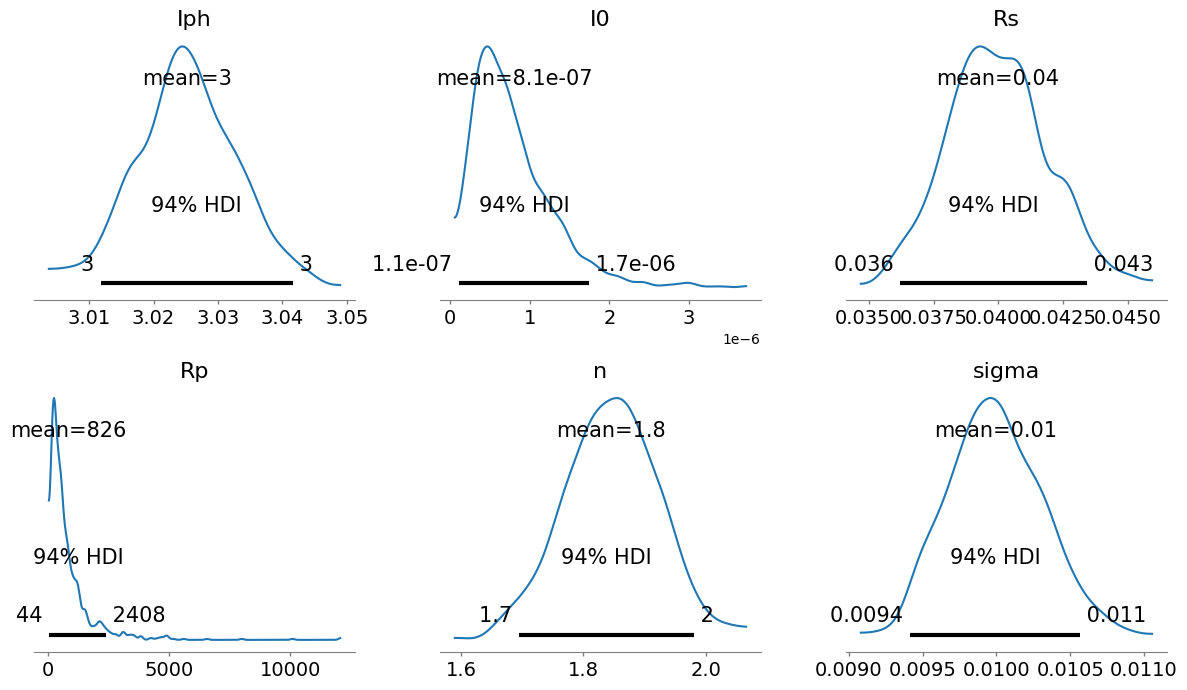

In [11]:
if "summary_log" not in globals() or "idata_log" not in globals():
    raise RuntimeError("Primero ejecutar la celda 33 para obtener summary_log e idata_log.")

posterior_means = summary_log["mean"].to_dict()
print("Media a posteriori de los parámetros (modelo log, celda 33):")
for k, v in posterior_means.items():
    print(f"- {k}: {v:.6g}")

pm.plot_posterior(
    idata_log,
    var_names=params,
    figsize=(12, 7),
    hdi_prob=0.94,
)
plt.tight_layout()
plt.show()

Esta salida confirma, en términos prácticos, lo que ya se venía observando en las celdas anteriores. Las medias a posteriori del modelo log son:

- $I_{ph}=3.0251$
- $I_0\approx 8.1 e-7$
- $R_s=0.04$
- $R_p=826.374$
- $n=1.8461$
- $\sigma=0.01$

La interpretación física es consistente. En particular, $I_0$ es relativamente chica porque corresponde a la corriente de saturación del diodo, que suele estar en órdenes de magnitud muy bajos.

Además, los gráficos posteriores muestran con claridad que la mayor incertidumbre está en $R_p$: su distribución es bastante más ancha que la de parámetros como $I_{ph}$, $R_s$, $n$ y $\sigma$. Esto es coherente con la identificabilidad del problema, ya que los datos restringen mejor los parámetros que dominan la forma principal de la curva y dejan más libertad en $R_p$.

Al comparar con las predicciones del inciso (a), el resultado es correcto en orden de magnitud: $I_{ph}$ en amperes, $I_0$ muy pequeño, $R_s$ baja, $R_p$ alta y $n$ dentro del rango físico esperado para un diodo no ideal. Por lo tanto, esta celda funciona como convalidación de las hipótesis iniciales y del análisis de convergencia previo, más que como una conclusión nueva.

### Predicción posterior y validación del modelo

En este punto se utiliza la distribución posterior de los parámetros para simular la salida del modelo, es decir, resolver nuevamente el problema directo pero incorporando la incertidumbre estimada.

A partir de las muestras obtenidas de $\theta$, se generan predicciones de la tensión para distintos valores de $R_L$. Esto da lugar a una distribución predictiva, en lugar de una única curva.

El objetivo es comparar estas predicciones con los datos experimentales.

Esta comparación permite evaluar si el modelo, utilizando parámetros inferidos, es capaz de reproducir adecuadamente las observaciones.

En términos prácticos, se espera que:

- las mediciones reales queden contenidas dentro de la banda de incertidumbre,
- la predicción siga la tendencia de los datos,
- y no existan desvíos sistemáticos importantes.

Este paso cierra el proceso de inferencia, ya que conecta la estimación de parámetros con la capacidad del modelo de describir el comportamiento observado del sistema.

Output()

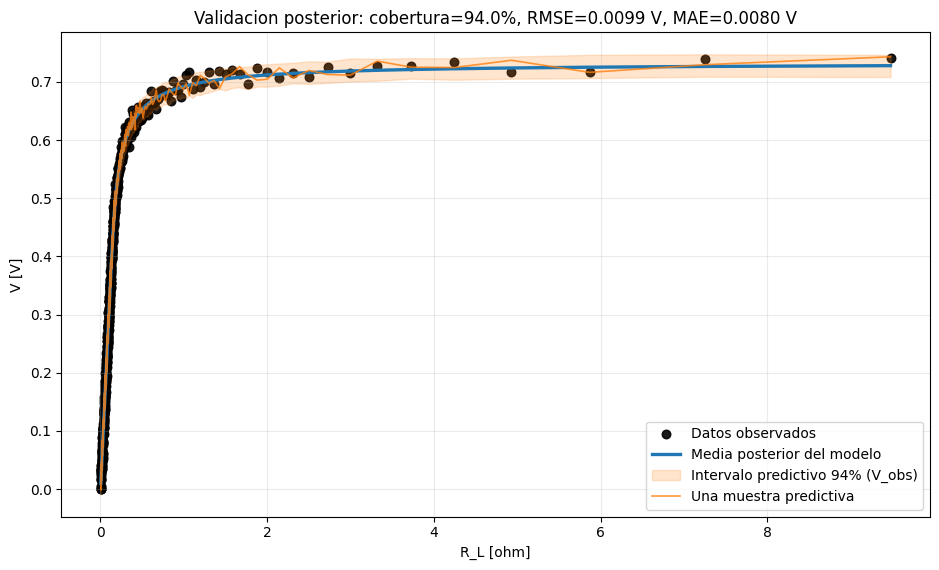

In [15]:
if "idata_log" not in globals() or "model_pv_log" not in globals():
    raise RuntimeError("Primero ejecutar la celda 33 para obtener idata_log y model_pv_log.")
if "RL_use" not in globals() or "V_use" not in globals():
    raise RuntimeError("No se encontraron RL_use y V_use. Ejecutar las celdas de carga/preprocesado.")

# Submuestreo para acelerar el posterior predictivo
idata_pp = idata_log.sel(draw=slice(None, None, 2))
with model_pv_log:
    ppc = pm.sample_posterior_predictive(
        idata_pp,
        var_names=["V_obs", "V_mu"],
        random_seed=126,
    )

# Media posterior de la respuesta latente del modelo
vmu_pp = ppc.posterior_predictive["V_mu"]
vmu_mean = vmu_pp.mean(dim=("chain", "draw")).values

# Intervalo creible predictivo (sobre V_obs) para comparar con mediciones reales
vobs_pp = ppc.posterior_predictive["V_obs"]
vobs_hdi = az.hdi(vobs_pp, hdi_prob=0.94)

if hasattr(vobs_hdi, "data_vars"):
    vobs_hdi_da = vobs_hdi["V_obs"]
else:
    vobs_hdi_da = vobs_hdi

vobs_low = np.asarray(vobs_hdi_da.sel(hdi="lower")).reshape(-1)
vobs_high = np.asarray(vobs_hdi_da.sel(hdi="higher")).reshape(-1)

# Una realizacion predictiva de V_obs para comparacion visual
vobs_samples = vobs_pp.stack(sample=("chain", "draw")).values
rng = np.random.default_rng(126)
idx = rng.integers(vobs_samples.shape[1])
vobs_one = vobs_samples[:, idx]

# Metricas simples de ajuste visual/cuanti
res = V_use - vmu_mean
rmse = np.sqrt(np.mean(res**2))
mae = np.mean(np.abs(res))
coverage = np.mean((V_use >= vobs_low) & (V_use <= vobs_high))

# Orden para graficar la curva de forma continua
order = np.argsort(RL_use)
rl_ord = RL_use[order]

plt.figure(figsize=(9.5, 5.8))
plt.scatter(RL_use, V_use, s=38, color="black", alpha=0.9, label="Datos observados")
plt.plot(rl_ord, vmu_mean[order], color="C0", lw=2.4, label="Media posterior del modelo")
plt.fill_between(
    rl_ord,
    vobs_low[order],
    vobs_high[order],
    color="C1",
    alpha=0.20,
    label="Intervalo predictivo 94% (V_obs)",
)
plt.plot(rl_ord, vobs_one[order], color="C1", lw=1.2, alpha=0.8, label="Una muestra predictiva")

plt.title(
    f"Validacion posterior: cobertura={coverage:.1%}, RMSE={rmse:.4f} V, MAE={mae:.4f} V"
)
plt.xlabel("R_L [ohm]")
plt.ylabel("V [V]")
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

El gráfico de predicción posterior muestra una excelente concordancia entre las predicciones del modelo y los datos experimentales.

La media posterior del modelo reproduce adecuadamente la forma de la curva observada en todo el rango de valores de $R_L$, incluyendo la región no lineal inicial y la zona de saturación.

El intervalo predictivo del $94\%$ contiene aproximadamente el $94\%$ de las observaciones, lo que indica una correcta calibración de la incertidumbre del modelo.

Las métricas de error (RMSE ≈ 0.01 V y MAE ≈ 0.008 V) cuantifican qué tan cerca están las predicciones del modelo respecto de los datos observados.

En particular:

- **MAE (Mean Absolute Error)** mide el error promedio en valor absoluto, es decir, la diferencia promedio entre la tensión predicha y la medida, sin importar el signo. Representa, en promedio, cuánto se desvía la predicción de un dato real.

- **RMSE (Root Mean Square Error)** mide el error cuadrático medio, penalizando más fuertemente los errores grandes. Esto lo hace más sensible a desviaciones importantes entre el modelo y los datos.

En este caso, ambos errores son del orden de 0.01 V, lo que indica que las predicciones del modelo difieren muy poco de las observaciones experimentales en todo el rango analizado.

En conjunto, estos resultados muestran que el modelo, utilizando los parámetros inferidos, no solo describe adecuadamente el comportamiento medio del sistema, sino también la variabilidad observada en los datos.